## Probability Density Function

### 1. Introduction

A **Probability Density Function (PDF)** is used to describe the distribution of a **continuous random variable**.

A PDF shows how the probability is distributed across the possible values of a continuous random variable.

Examples of continuous random variables include:

- Height
- Weight
- Temperature
- Time
- Distance
- Age

Unlike a PMF, a PDF does **not** directly give the probability of an exact value.

Instead, the **area under the PDF curve over an interval represents probability**.


### 2. Intuition



Consider the height of randomly selected people.

Height is continuous because it can take many possible values:

$$
170,\ 170.1,\ 170.15,\ 170.153,\ldots
$$

Instead of assigning a separate probability to every possible height, we describe how the probability is distributed across ranges of heights.

For example, we might ask:

> What is the probability that a person's height is between 165 cm and 170 cm?

The PDF helps us answer this question.

The important idea is:

$$
\boxed{\text{Probability over an interval}=\text{Area under the PDF curve}}
$$

### Most Important Point

A common mistake is to think that the height of a PDF curve directly represents probability.

It does not.

The value of the PDF at a particular point represents **probability density**, not probability.

For example:

$$
f(170)
$$

is the density at 170 cm.

It is **not**:

$$
P(X=170)
$$

For a continuous random variable:

$$
P(X=170)=0
$$

Instead, we calculate probabilities over intervals.

For example:

$$
P(165<X<170)
$$

is represented by the area under the PDF curve between 165 and 170.

### 3. Formula

A probability density function is generally represented as:

$$
f(x)
$$

For a valid PDF, two important conditions must be satisfied.

#### 1. PDF cannot be negative

$$
f(x)\geq0
$$

#### 2. Total area under the curve must equal 1

$$
\int_{-\infty}^{\infty}f(x)\,dx=1
$$

The probability that a continuous random variable lies between \(a\) and \(b\) is:

$$
P(a\leq X\leq b)
=
\int_a^b f(x)\,dx
$$

In simple terms:

> **Probability = area under the PDF curve over the required interval.**

### 4. Visual Intuition

Imagine a PDF curve:

                 PDF
                  │
                  │        ╭──╮
                  │      ╭─╯  ╰─╮
                  │    ╭─╯      ╰─╮
                  │  ╭─╯          ╰─╮
                  └─────────────────────→ X
                       a        b

The area between \(a\) and \(b\) represents:

$$
P(a<X<b)
$$

Therefore:

- Height of the curve → probability density
- Area under the curve → probability
- Total area → 1

### 5. Why Probability is exactly zero

This is one of the most important differences between discrete and continuous random variables.

Suppose:

$$
X=\text{height of a person}
$$

We could ask:

$$
P(X=170)
$$

For a continuous random variable:

$$
P(X=170)=0
$$

This is because there are infinitely many possible values around 170:

$$
169.999,\ 169.9999,\ 170,\ 170.0001,\ 170.001,\ldots
$$

A single exact point has no area.

However, an interval has area.

Therefore:

$$
P(169<X<171)>0
$$

The probability comes from the **area across a range**, not from one exact point.

### 6. PMF vs PDF

| Feature | PMF | PDF |
|---|---|---|
| Used for | Discrete variables | Continuous variables |
| Gives | Probability of an exact value | Probability density |
| Exact value probability | Can be greater than 0 | Generally 0 |
| Probability calculated using | Individual probability | Area under curve |
| Visualization | Usually bars | Usually a smooth curve |

#### Remember

$$
\boxed{\text{Discrete}\rightarrow\text{PMF}}
$$

$$
\boxed{\text{Continuous}\rightarrow\text{PDF}}
$$ \(1/6\) probability of rolling a 3.

### 7. Python Implementation




We can use SciPy to work with probability distributions.

For this example, we will use a normal distribution to demonstrate the idea of a PDF.

The normal distribution will be studied in greater detail in a separate notebook.

For now, we are only using it to understand how a PDF works.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(-4, 4, 1000)

pdf = stats.norm.pdf(x)

print(pdf[:10])

[0.00013383 0.00013818 0.00014267 0.00014729 0.00015205 0.00015695
 0.000162   0.00016721 0.00017257 0.00017809]


### 8. Visualization

The PDF can be visualized as a continuous curve.

The curve shows the probability density at different values of the random variable.

Remember:

> The height of the curve is density, not probability.

The probability of an interval is represented by the area under the curve.

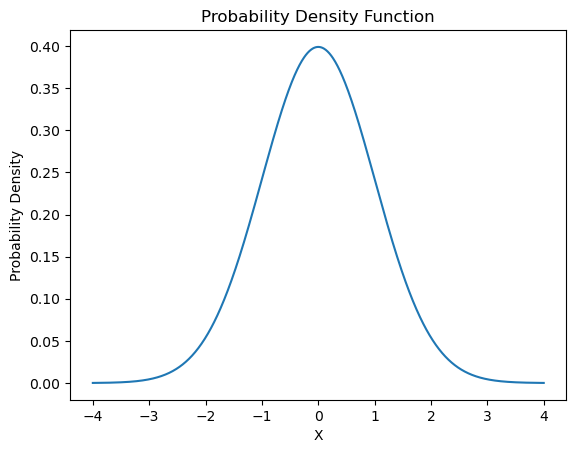

In [17]:
plt.plot(x, pdf)

plt.xlabel("X")
plt.ylabel("Probability Density")
plt.title("Probability Density Function")

plt.show()

### 9. Area Represents Probability

#### 🎨 Area Under the Curve

Suppose we want to find:

$$
P(-1<X<1)
$$

We can visualize this probability by shading the area under the PDF curve between -1 and 1.

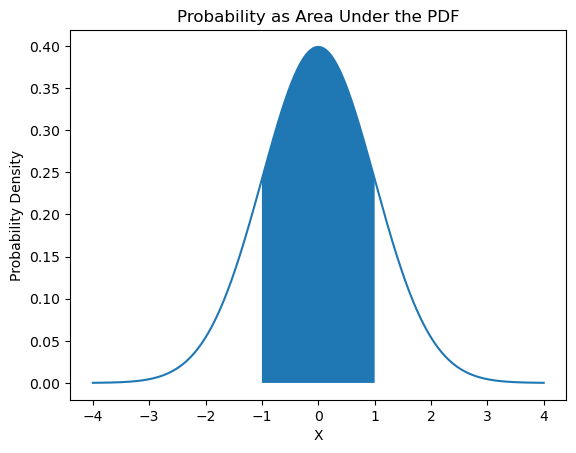

In [21]:
x = np.linspace(-4, 4, 1000)
pdf = stats.norm.pdf(x)

plt.plot(x, pdf)

x_fill = np.linspace(-1, 1, 500)
y_fill = stats.norm.pdf(x_fill)

plt.fill_between(x_fill, y_fill)

plt.xlabel("X")
plt.ylabel("Probability Density")
plt.title("Probability as Area Under the PDF")

plt.show()

### 10. Calculating Probability from a PDF



For a continuous distribution, probability over an interval can be calculated using the cumulative distribution function.

For example:

$$
P(-1<X<1)
$$

can be calculated as:

$$
P(-1<X<1)
=
F(1)-F(-1)
$$

where \(F(x)\) is the CDF.

We will study the CDF in the next section.

In [25]:
probability = stats.norm.cdf(1) - stats.norm.cdf(-1)

print("P(-1 < X < 1):", probability)

P(-1 < X < 1): 0.6826894921370859


### 11.  Probability Distribution vs PDF

Suppose:

$$
f(0)=0.3989
$$

This does **not** mean:

$$
P(X=0)=0.3989
$$

Instead, 0.3989 is the **density** at \(X=0\).

To calculate probability, we need an interval and find the area under the curve.

For example:

$$
P(-1<X<1)
$$

is a probability because it represents an area under the curve.

#### Remember

> **PDF height = density**

> **PDF area = probability**

### 12. Real Dataset Example — Titanic

We can use the `Age` variable from the Titanic dataset to visualize an empirical continuous distribution.

Age is treated as a continuous variable because it can theoretically take many values within a range.

We will use a histogram with a density scale to approximate the distribution of passenger ages.

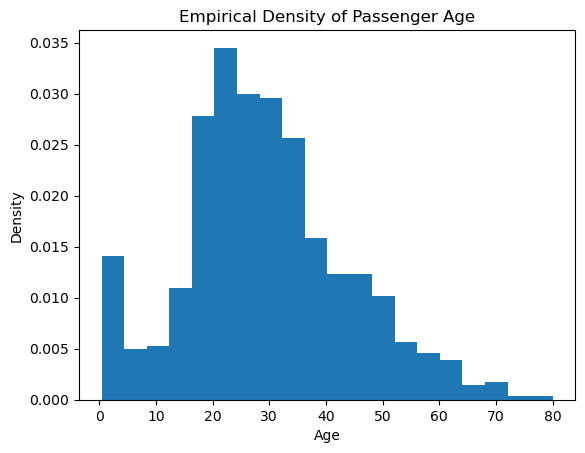

In [36]:
import pandas as pd
df = pd.read_csv(r"C:\Users\WIN 10\Documents\stats and probability\Titanic-Dataset.csv")
age = df["Age"].dropna()

plt.hist(age, bins=20, density=True)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Empirical Density of Passenger Age")

plt.show()


The histogram represents the empirical distribution of passenger ages.

Using:

$$
density=True
$$

normalizes the histogram so that the total area is approximately 1.

This allows us to interpret the histogram as an approximation of a probability density.

For example, a region with a larger density indicates that passenger ages are more concentrated in that range.

However, this is an **empirical distribution**, not necessarily a theoretical PDF.

### 13. Business Applications


PDFs are useful when businesses work with continuous measurements.

####  ⏱️ Customer Waiting Time

A company can model the distribution of customer waiting times.

For example:

$$
P(5<X<10)
$$

could represent the probability that a customer waits between 5 and 10 minutes.

####  💰 Customer Spending

A business can study the distribution of how much customers spend.

####  🚚 Delivery Time

A logistics company can analyze the probability distribution of delivery times.

####  🏭 Manufacturing

A manufacturer can model measurements such as:

- Product weight
- Product length
- Temperature
- Machine measurements

####  Key Takeaway

PDFs help businesses understand how continuous measurements are distributed and calculate the probability that a measurement falls within a particular range.ng appropriate dful when building probabilistic models.king.ty-weighted average outcomes.

### 14. ML Connection


Probability density functions are important in machine learning because they allow us to model the distribution of continuous data.

#### Density Estimation

We can estimate the underlying distribution of continuous data.

#### Gaussian Models

Many machine learning and statistical techniques use Gaussian distributions to model continuous variables.

#### Anomaly Detection

If a data point falls in a region of very low probability density, it may be considered unusual or potentially anomalous.

#### Probabilistic Models

PDFs are used in models where we want to estimate how likely observed continuous values are.

For example, a model might estimate:

$$
P(X=x)
$$

through a probability density rather than assigning probability directly to the exact value.

#### Key Takeaway

PDFs allow machine learning models to describe and reason about the distribution of continuous variables.els.ons when outcomes are uncertain.

We can visualize the empirical PMF of `SibSp` using a bar chart.

Each bar represents the observed probability of a particular number of siblings or spouses aboard.

### 15. Key Takeaways

- PDF stands for **Probability Density Function**.
- PDF is used for **continuous random variables**.
- The height of a PDF represents **probability density**, not probability.
- Probability is represented by the **area under the PDF curve**.
- The total area under a valid PDF is:

$$
\int_{-\infty}^{\infty}f(x)\,dx=1
$$

- For a continuous variable:

$$
P(X=x)=0
$$

for an exact individual value.

- Probability over an interval is:

$$
P(a<X<b)=\int_a^b f(x)\,dx
$$

- PMF is used for discrete variables.
- PDF is used for continuous variables.

### Remember

$$
\boxed{\text{PMF → Probability at a discrete value}}
$$

$$
\boxed{\text{PDF → Density across continuous values}}
$$

$$
\boxed{\text{Area under PDF → Probability}}
$$of a discrete random variable.**